In [1]:
!pip install segmentation_models_pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 10.7 MB/s eta 0:00:00


In [2]:
import os
import math
import random
from pathlib import Path
from PIL import Image, ImageFilter, ImageEnhance

import cv2
import numpy as np
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import torch.nn.functional as F
from torchvision.transforms import InterpolationMode

import gc
from tqdm import tqdm
import matplotlib.pyplot as plt

from transformers import SegformerForSemanticSegmentation

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

img_dir = Path("/kaggle/input/datasets/karmagames/wrinkles-dataset/clean_roi/clean_roi")
mask_dir = Path("/kaggle/input/datasets/karmagames/wrinkles-dataset/manual_wrinkle_masks/manual_wrinkle_masks")

torch.backends.cudnn.benchmark = True
# os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
# os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"


import segmentation_models_pytorch as smp
import random
from pathlib import Path
import numpy as np
import cv2
import torch
from torch.utils.data import Dataset
from torchvision import transforms
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode


IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)


In [3]:
class RandomGamma:
    def __init__(self, gamma_range=(0.9, 1.1), p=0.3):
        self.gamma_range = gamma_range
        self.p = p

    def __call__(self, img):
        if random.random() > self.p:
            return img
        gamma = random.uniform(*self.gamma_range)
        return TF.adjust_gamma(img, gamma)


class RandomGaussianBlur:
    def __init__(self, radius_range=(0.1, 0.6), p=0.2):
        self.radius_range = radius_range
        self.p = p

    def __call__(self, img):
        if random.random() > self.p:
            return img
        radius = random.uniform(*self.radius_range)
        return img.filter(ImageFilter.GaussianBlur(radius))


class CLAHELabTransform:
    def __init__(self, clip_limit=1, tile_grid_size=(8, 8), p=0.25):
        self.clip_limit = clip_limit
        self.tile_grid_size = tile_grid_size
        self.p = p

    def __call__(self, img):
        if random.random() > self.p:
            return img

        img_np = np.array(img)
        lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)

        clahe = cv2.createCLAHE(
            clipLimit=self.clip_limit,
            tileGridSize=self.tile_grid_size
        )
        l = clahe.apply(l)

        lab = cv2.merge([l, a, b])
        out = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
        return Image.fromarray(out)


class WrinkleSegDatasetV2(Dataset):
    def __init__(self, pairs, img_size=1024, train=False, rgb=True):
        self.pairs = pairs
        self.train = train
        self.rgb = rgb
        self.img_size = img_size

        self.normalize = transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )

        self.color_aug = transforms.Compose([
            transforms.ColorJitter(
                brightness=0.20,
                contrast=0.20,
                saturation=0.08,
                hue=0.015
            ),
            RandomGamma(gamma_range=(0.80, 1.25), p=0.50),
            RandomGaussianBlur(radius_range=(0.1, 0.8), p=0.20),
        ])

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        img = Image.open(img_path)
        img = img.convert("RGB") if self.rgb else img.convert("L")
        mask = Image.open(mask_path).convert("L")

        # resize first
        img = TF.resize(img, [self.img_size, self.img_size], interpolation=InterpolationMode.BILINEAR)
        mask = TF.resize(mask, [self.img_size, self.img_size], interpolation=InterpolationMode.NEAREST)

        # geometric aug (same for image & mask)
        if self.train:
            if random.random() < 0.5:
                img = TF.hflip(img)
                mask = TF.hflip(mask)

            if random.random() < 0.15:
                img = TF.vflip(img)
                mask = TF.vflip(mask)

            angle = random.uniform(-10, 10)
            img = TF.rotate(img, angle, interpolation=InterpolationMode.BILINEAR)
            mask = TF.rotate(mask, angle, interpolation=InterpolationMode.NEAREST)

            img = self.color_aug(img)

        x = TF.to_tensor(img)
        x = self.normalize(x)

        y = TF.to_tensor(mask)
        y = (y > 0.5).float()

        return x, y


def denormalize(img, mean, std):
    """
    img: tensor [C,H,W]
    """
    img = img.clone()
    for c in range(img.shape[0]):
        img[c] = img[c] * std[c] + mean[c]
    return img

def show_batch_with_masks(loader):
    imgs, masks = next(iter(loader))

    imgs = imgs.cpu()
    masks = masks.cpu()

    B = imgs.shape[0]

    fig, axes = plt.subplots(2, B, figsize=(3 * B, 6))

    for i in range(B):

        img = denormalize(imgs[i], IMAGENET_MEAN, IMAGENET_STD)

        img = img.numpy().transpose(1, 2, 0)
        mask = masks[i, 0].numpy()

        img = np.clip(img, 0, 1)

        axes[0, i].imshow(img)
        axes[0, i].axis("off")

        axes[1, i].imshow(mask, cmap="gray")
        axes[1, i].axis("off")

    axes[0, B // 2].set_title("Top: Images | Bottom: Masks")

    plt.tight_layout()
    plt.show()

In [4]:
image_paths = sorted(img_dir.glob("*.png"))

pairs = []

for img_path in image_paths:
    mask_path = mask_dir / img_path.name
    
    if mask_path.exists():
        pairs.append((img_path, mask_path))
    else:
        print(f"⚠ Mask not found for {img_path.name}")

print(f"Recovered {len(pairs)} pairs successfully.")
pairs[:3]

Recovered 1000 pairs successfully.


[(PosixPath('/kaggle/input/datasets/karmagames/wrinkles-dataset/clean_roi/clean_roi/00001.png'),
  PosixPath('/kaggle/input/datasets/karmagames/wrinkles-dataset/manual_wrinkle_masks/manual_wrinkle_masks/00001.png')),
 (PosixPath('/kaggle/input/datasets/karmagames/wrinkles-dataset/clean_roi/clean_roi/00011.png'),
  PosixPath('/kaggle/input/datasets/karmagames/wrinkles-dataset/manual_wrinkle_masks/manual_wrinkle_masks/00011.png')),
 (PosixPath('/kaggle/input/datasets/karmagames/wrinkles-dataset/clean_roi/clean_roi/00016.png'),
  PosixPath('/kaggle/input/datasets/karmagames/wrinkles-dataset/manual_wrinkle_masks/manual_wrinkle_masks/00016.png'))]

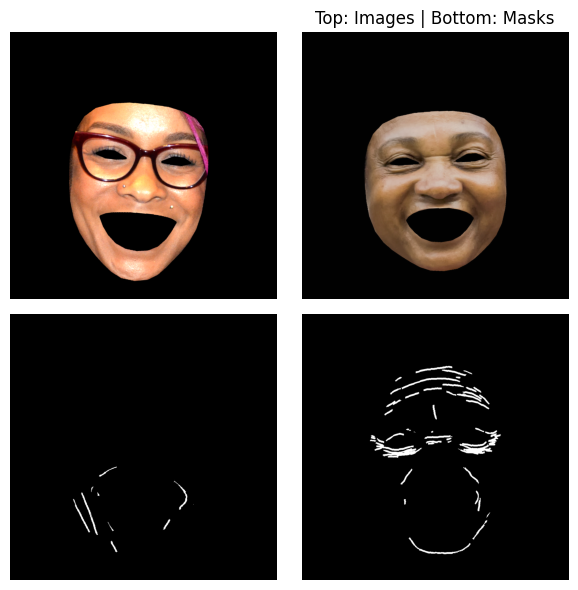

train/dev/test: 400 50 50


In [5]:
IMG_SIZE = 1024
BATCH_SIZE = 2
NUM_EPOCHS = 45

train_pairs, temp_pairs = train_test_split(
    pairs, test_size=0.2, random_state=42, shuffle=True
)

dev_pairs, test_pairs = train_test_split(
    temp_pairs, test_size=0.5, random_state=42, shuffle=True
)

ds_tr = WrinkleSegDatasetV2(train_pairs, img_size=IMG_SIZE, train=True, rgb=True)
ds_dev = WrinkleSegDatasetV2(dev_pairs, img_size=IMG_SIZE, train=False, rgb=True)
ds_te = WrinkleSegDatasetV2(test_pairs, img_size=IMG_SIZE, train=False, rgb=True)

train_loader = DataLoader(ds_tr, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(ds_dev, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(ds_te, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

show_batch_with_masks(train_loader)

print("train/dev/test:", len(train_loader), len(val_loader), len(test_loader))

In [6]:

bce_loss = nn.BCEWithLogitsLoss()

def dice_loss(logits, targets, smooth=1.0):
    probs = torch.sigmoid(logits)

    probs = probs.view(probs.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    intersection = (probs * targets).sum(dim=1)
    dice = (2.0 * intersection + smooth) / (
        probs.sum(dim=1) + targets.sum(dim=1) + smooth
    )

    return 1.0 - dice.mean()


def bce_dice_loss(logits, targets):
    return bce_loss(logits, targets) + dice_loss(logits, targets)


def batch_iou_dice(logits, targets, threshold=0.5, eps=1e-8):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    preds = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    intersection = (preds * targets).sum(dim=1)
    union = preds.sum(dim=1) + targets.sum(dim=1) - intersection

    iou = (intersection + eps) / (union + eps)
    dice = (2 * intersection + eps) / (preds.sum(dim=1) + targets.sum(dim=1) + eps)

    return iou.mean().item(), dice.mean().item()


def train_one_epoch(model, loader, optimizer, device, ep, epochs):
    model.train()

    running_loss = 0.0
    running_iou = 0.0
    running_dice = 0.0
    
    pbar = tqdm(loader, desc=f"epoch {ep}/{epochs}", leave=False)

    for imgs, masks in pbar:
        imgs = imgs.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        logits = model(imgs)
        loss = bce_dice_loss(logits, masks)

        loss.backward()
        optimizer.step()

        iou, dice = batch_iou_dice(logits.detach(), masks)

        running_loss += loss.item()
        running_iou += iou
        running_dice += dice

    n = len(loader)
    return {
        "loss": running_loss / n,
        "iou": running_iou / n,
        "dice": running_dice / n,
    }


@torch.no_grad()
def validate_one_epoch(model, loader, device, threshold=0.5, eps=1e-8):
    model.eval()

    running_loss = 0.0
    running_iou = 0.0
    running_dice = 0.0

    # для глобальних метрик
    total_tp = 0.0
    total_fp = 0.0
    total_fn = 0.0
    total_tn = 0.0

    for imgs, masks in loader:
        imgs = imgs.to(device)
        masks = masks.to(device)

        logits = model(imgs)
        loss = bce_dice_loss(logits, masks)

        # базові метрики
        iou, dice = batch_iou_dice(logits, masks)

        running_loss += loss.item()
        running_iou += iou
        running_dice += dice

        # ===== нове: pixel-level метрики =====
        probs = torch.sigmoid(logits)
        preds = (probs > threshold).float()

        tp = (preds * masks).sum().item()
        fp = (preds * (1 - masks)).sum().item()
        fn = ((1 - preds) * masks).sum().item()
        tn = ((1 - preds) * (1 - masks)).sum().item()

        total_tp += tp
        total_fp += fp
        total_fn += fn
        total_tn += tn

    n = len(loader)

    # ===== фінальні метрики =====
    accuracy = (total_tp + total_tn) / (total_tp + total_tn + total_fp + total_fn + eps)
    precision = total_tp / (total_tp + total_fp + eps)
    recall = total_tp / (total_tp + total_fn + eps)

    return {
        "loss": running_loss / n,
        "iou": running_iou / n,
        "dice": running_dice / n,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
    }


@torch.no_grad()
def predict_batch(model, loader, device, threshold=0.5):
    model.eval()
    imgs, masks = next(iter(loader))

    imgs = imgs.to(device)
    masks = masks.to(device)

    logits = model(imgs)
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    return imgs.cpu(), masks.cpu(), logits.cpu(), preds.cpu(), probs.cpu()


def single_iou_dice(logit, target, threshold=0.5, eps=1e-8):
    """
    logit: tensor [1, H, W] або [H, W]
    target: tensor [1, H, W] або [H, W]
    """
    if logit.ndim == 3:
        logit = logit.squeeze(0)
    if target.ndim == 3:
        target = target.squeeze(0)

    prob = torch.sigmoid(logit)
    pred = (prob > threshold).float()

    pred = pred.view(-1)
    target = target.view(-1)

    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection

    iou = (intersection + eps) / (union + eps)
    dice = (2 * intersection + eps) / (pred.sum() + target.sum() + eps)

    return iou.item(), dice.item(), prob.cpu().numpy()


def denormalize_imagenet(img):
    """
    img: tensor [3, H, W] після Normalize(mean, std)
    """
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    img = img.cpu().numpy().transpose(1, 2, 0)
    img = img * std + mean
    return np.clip(img, 0, 1)


def show_predictions_overlay(imgs, masks, logits, n=4, threshold=0.5, alpha=0.45):
    import numpy as np
    import matplotlib.pyplot as plt

    def make_error_overlay(img, pred, gt, alpha=0.45):
        pred = pred.astype(bool)
        gt = gt.astype(bool)

        tp = pred & gt
        fp = pred & (~gt)
        fn = (~pred) & gt

        overlay = img.copy()

        # TP → green
        overlay[tp] = (1 - alpha) * overlay[tp] + alpha * np.array([0.0, 1.0, 0.0])

        # FP → red
        overlay[fp] = (1 - alpha) * overlay[fp] + alpha * np.array([1.0, 0.0, 0.0])

        # FN → blue
        overlay[fn] = (1 - alpha) * overlay[fn] + alpha * np.array([0.0, 0.0, 1.0])

        return np.clip(overlay, 0, 1)

    n = min(n, imgs.shape[0])
    fig, ax = plt.subplots(n, 4, figsize=(16, 4 * n))

    if n == 1:
        ax = np.expand_dims(ax, axis=0)

    for i in range(n):
        img = denormalize_imagenet(imgs[i])

        gt = masks[i, 0].cpu().numpy()

        # 👇 використовуємо твою функцію
        iou, dice, prob = single_iou_dice(logits[i], masks[i], threshold=threshold)

        pred = (prob > threshold).astype(np.float32)

        overlay = make_error_overlay(img, pred, gt, alpha=alpha)

        # Image
        ax[i, 0].imshow(img)
        ax[i, 0].set_title("Image")
        ax[i, 0].axis("off")

        # GT
        ax[i, 1].imshow(gt, cmap="gray")
        ax[i, 1].set_title("Ground Truth")
        ax[i, 1].axis("off")

        # Prediction
        ax[i, 2].imshow(pred, cmap="gray")
        ax[i, 2].set_title(f"Pred\nDice={dice:.3f} IoU={iou:.3f}")
        ax[i, 2].axis("off")

        # Overlay
        ax[i, 3].imshow(overlay)
        ax[i, 3].set_title("Overlay\nGreen=TP Red=FP Blue=FN")
        ax[i, 3].axis("off")

    plt.tight_layout()
    plt.show()

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = smp.Unet(
    encoder_name="efficientnet-b3",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=40
)

Device: cuda


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

In [8]:
num_epochs = 40
best_val_dice = -1.0

history = {
    "train_loss": [],
    "train_iou": [],
    "train_dice": [],
    "val_loss": [],
    "val_iou": [],
    "val_dice": [],
}

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, optimizer, device, epoch, num_epochs)
    val_metrics = validate_one_epoch(model, val_loader, device)

    scheduler.step()

    history["train_loss"].append(train_metrics["loss"])
    history["train_iou"].append(train_metrics["iou"])
    history["train_dice"].append(train_metrics["dice"])

    history["val_loss"].append(val_metrics["loss"])
    history["val_iou"].append(val_metrics["iou"])
    history["val_dice"].append(val_metrics["dice"])

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"train_loss={train_metrics['loss']:.4f}, train_iou={train_metrics['iou']:.4f}, train_dice={train_metrics['dice']:.4f} | "
        f"val_loss={val_metrics['loss']:.4f}, val_iou={val_metrics['iou']:.4f}, val_dice={val_metrics['dice']:.4f}"
    )

    if val_metrics["dice"] > best_val_dice:
        best_val_dice = val_metrics["dice"]
        torch.save(model.state_dict(), "best_unet_efficientnetb0_imagenet.pth")
        print("Saved best model.")

Epoch [1/40] | train_loss=0.9616, train_iou=0.2269, train_dice=0.3461 | val_loss=0.5751, val_iou=0.3473, val_dice=0.5058
Saved best model.


Epoch [2/40] | train_loss=0.5285, train_iou=0.3651, train_dice=0.5254 | val_loss=0.5055, val_iou=0.3821, val_dice=0.5405
Saved best model.


Epoch [3/40] | train_loss=0.4860, train_iou=0.3941, train_dice=0.5560 | val_loss=0.4811, val_iou=0.4006, val_dice=0.5612
Saved best model.


Epoch [4/40] | train_loss=0.4724, train_iou=0.4034, train_dice=0.5668 | val_loss=0.4752, val_iou=0.4030, val_dice=0.5639
Saved best model.


Epoch [5/40] | train_loss=0.4610, train_iou=0.4128, train_dice=0.5763 | val_loss=0.4606, val_iou=0.4142, val_dice=0.5764
Saved best model.


...

Epoch [36/40] | train_loss=0.3544, train_iou=0.5142, train_dice=0.6733 | val_loss=0.4220, val_iou=0.4471, val_dice=0.6097


Epoch [37/40] | train_loss=0.3531, train_iou=0.5153, train_dice=0.6745 | val_loss=0.4203, val_iou=0.4482, val_dice=0.6112
Saved best model.


Epoch [38/40] | train_loss=0.3518, train_iou=0.5165, train_dice=0.6757 | val_loss=0.4204, val_iou=0.4483, val_dice=0.6114
Saved best model.


Epoch [39/40] | train_loss=0.3522, train_iou=0.5163, train_dice=0.6754 | val_loss=0.4211, val_iou=0.4478, val_dice=0.6108


Epoch [40/40] | train_loss=0.3519, train_iou=0.5166, train_dice=0.6755 | val_loss=0.4207, val_iou=0.4479, val_dice=0.6109


In [10]:
def get_non_black_mask_from_normalized(imgs, threshold=0.03):
    """
    imgs: [B, 3, H, W], normalized by ImageNet mean/std
    return: [B, 1, H, W], де 1 = не чорний фон
    """
    mean = torch.tensor([0.485, 0.456, 0.406], device=imgs.device).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225], device=imgs.device).view(1, 3, 1, 1)

    imgs_denorm = imgs * std + mean
    imgs_denorm = imgs_denorm.clamp(0, 1)

    # фон чорний, якщо всі канали майже 0
    valid_mask = (imgs_denorm > threshold).any(dim=1, keepdim=True).float()

    return valid_mask


@torch.no_grad()
def evaluate_segmentation_metrics(
    model,
    loader,
    device,
    threshold=0.5,
    black_threshold=0.03,
    eps=1e-8
):
    model.eval()

    total_tp = 0.0
    total_fp = 0.0
    total_fn = 0.0
    total_tn = 0.0

    for imgs, masks in loader:
        imgs = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True).float()

        logits = forward_logits(model, imgs)
        probs = torch.sigmoid(logits)
        preds = (probs > threshold).float()

        # область, де НЕ чорний фон
        valid_mask = get_non_black_mask_from_normalized(
            imgs,
            threshold=black_threshold
        )

        # залишаємо тільки валідну область
        preds = preds * valid_mask
        masks = masks * valid_mask

        tp = (preds * masks).sum().item()
        fp = (preds * (1 - masks) * valid_mask).sum().item()
        fn = ((1 - preds) * masks * valid_mask).sum().item()
        tn = ((1 - preds) * (1 - masks) * valid_mask).sum().item()

        total_tp += tp
        total_fp += fp
        total_fn += fn
        total_tn += tn

    precision = total_tp / (total_tp + total_fp + eps)
    recall = total_tp / (total_tp + total_fn + eps)
    iou = total_tp / (total_tp + total_fp + total_fn + eps)
    dice = (2 * total_tp) / (2 * total_tp + total_fp + total_fn + eps)
    accuracy = (total_tp + total_tn) / (
        total_tp + total_tn + total_fp + total_fn + eps
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "iou": iou,
        "dice": dice,
    }


def get_valid_non_black_mask_np(img, threshold=0.03):
    """
    img: [H, W, 3], already denormalized to [0, 1]
    return: [H, W], True там, де НЕ чорний фон
    """
    return (img > threshold).any(axis=2)


def visualize_predictions_grid(imgs, masks, preds, n=4, black_threshold=0.03):
    n = min(n, len(imgs))
    fig, axes = plt.subplots(n, 4, figsize=(18, 4 * n))


    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(n):
        img = denormalize_if_needed(imgs[i])  # [H, W, 3], [0, 1]
        gt = masks[i, 0].detach().cpu().numpy()
        pred = preds[i, 0].detach().cpu().numpy()

        # valid area: не чорний фон
        valid_mask = get_valid_non_black_mask_np(
            img,
            threshold=black_threshold
        )

        # прибираємо фон з gt і pred
        gt_valid = gt * valid_mask
        pred_valid = pred * valid_mask

        dice, iou = compute_metrics_single(pred_valid, gt_valid)

        overlay = make_error_overlay(
            img,
            pred_valid,
            gt_valid,
            alpha=0.45
        )

        # щоб фон у масках був явно чорний
        gt_show = gt.copy()
        pred_show = pred.copy()

        gt_show[~valid_mask] = 0
        pred_show[~valid_mask] = 0

        axes[i, 0].imshow(img)
        axes[i, 0].set_title("Image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(gt_show, cmap="gray")
        axes[i, 1].set_title("Ground Truth\nbackground removed")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(pred_show, cmap="gray")
        axes[i, 2].set_title(f"Prediction\nDice={dice:.3f}  IoU={iou:.3f}")
        axes[i, 2].axis("off")

        axes[i, 3].imshow(overlay)
        axes[i, 3].set_title("Overlay\nGreen=TP  Red=FP  Blue=FN")
        axes[i, 3].axis("off")

    plt.tight_layout()
    plt.show()

def forward_logits(model, imgs):
    """
    Універсальний forward, щоб завжди отримати logits [B, 1, H, W]
    """
    out = model(imgs)

    # якщо модель повертає dict (типу SegFormer)
    if isinstance(out, dict):
        if "out" in out:
            out = out["out"]
        elif "logits" in out:
            out = out["logits"]

    # якщо повертає tuple/list
    if isinstance(out, (list, tuple)):
        out = out[0]

    return out


@torch.no_grad()
def get_predictions_unet(model, loader, device, threshold=0.5):
    model.eval()

    imgs_all = []
    masks_all = []
    probs_all = []
    preds_all = []

    for imgs, masks in loader:
        imgs = imgs.to(device)
        masks = masks.to(device).float()

        logits = forward_logits(model, imgs)
        probs = torch.sigmoid(logits)
        preds = (probs > threshold).float()

        imgs_all.append(imgs.cpu())
        masks_all.append(masks.cpu())
        probs_all.append(probs.cpu())
        preds_all.append(preds.cpu())

    imgs_all = torch.cat(imgs_all, dim=0)
    masks_all = torch.cat(masks_all, dim=0)
    probs_all = torch.cat(probs_all, dim=0)
    preds_all = torch.cat(preds_all, dim=0)

    return imgs_all, masks_all, probs_all, preds_all




def compute_metrics_single(pred, gt, eps=1e-8):
    pred = pred.astype(np.float32)
    gt = gt.astype(np.float32)

    intersection = (pred * gt).sum()
    union = pred.sum() + gt.sum() - intersection

    iou = (intersection + eps) / (union + eps)
    dice = (2 * intersection + eps) / (pred.sum() + gt.sum() + eps)

    return dice, iou


def denormalize_if_needed(img):
    img = img.numpy().transpose(1, 2, 0)

    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std = np.array([0.229, 0.224, 0.225], dtype=np.float32)

    img = img * std + mean
    img = np.clip(img, 0, 1)
    return img


def make_error_overlay(img, pred, gt, alpha=0.45):
    pred = pred.astype(bool)
    gt = gt.astype(bool)

    tp = pred & gt
    fp = pred & (~gt)
    fn = (~pred) & gt

    overlay = img.copy()

    overlay[tp] = (1 - alpha) * overlay[tp] + alpha * np.array([0.0, 1.0, 0.0])
    overlay[fp] = (1 - alpha) * overlay[fp] + alpha * np.array([1.0, 0.0, 0.0])
    overlay[fn] = (1 - alpha) * overlay[fn] + alpha * np.array([0.0, 0.0, 1.0])

    return np.clip(overlay, 0, 1)


In [11]:
model.load_state_dict(torch.load("/kaggle/working/best_unet_efficientnetb0_imagenet.pth", map_location=device))
model.eval()


val_metrics = evaluate_segmentation_metrics(model, test_loader, device)
print(val_metrics)

{'accuracy': 0.9822792503391501, 'precision': 0.611868624277, 'recall': 0.6743454938078385, 'iou': 0.47230918708841124, 'dice': 0.6415896759055534}


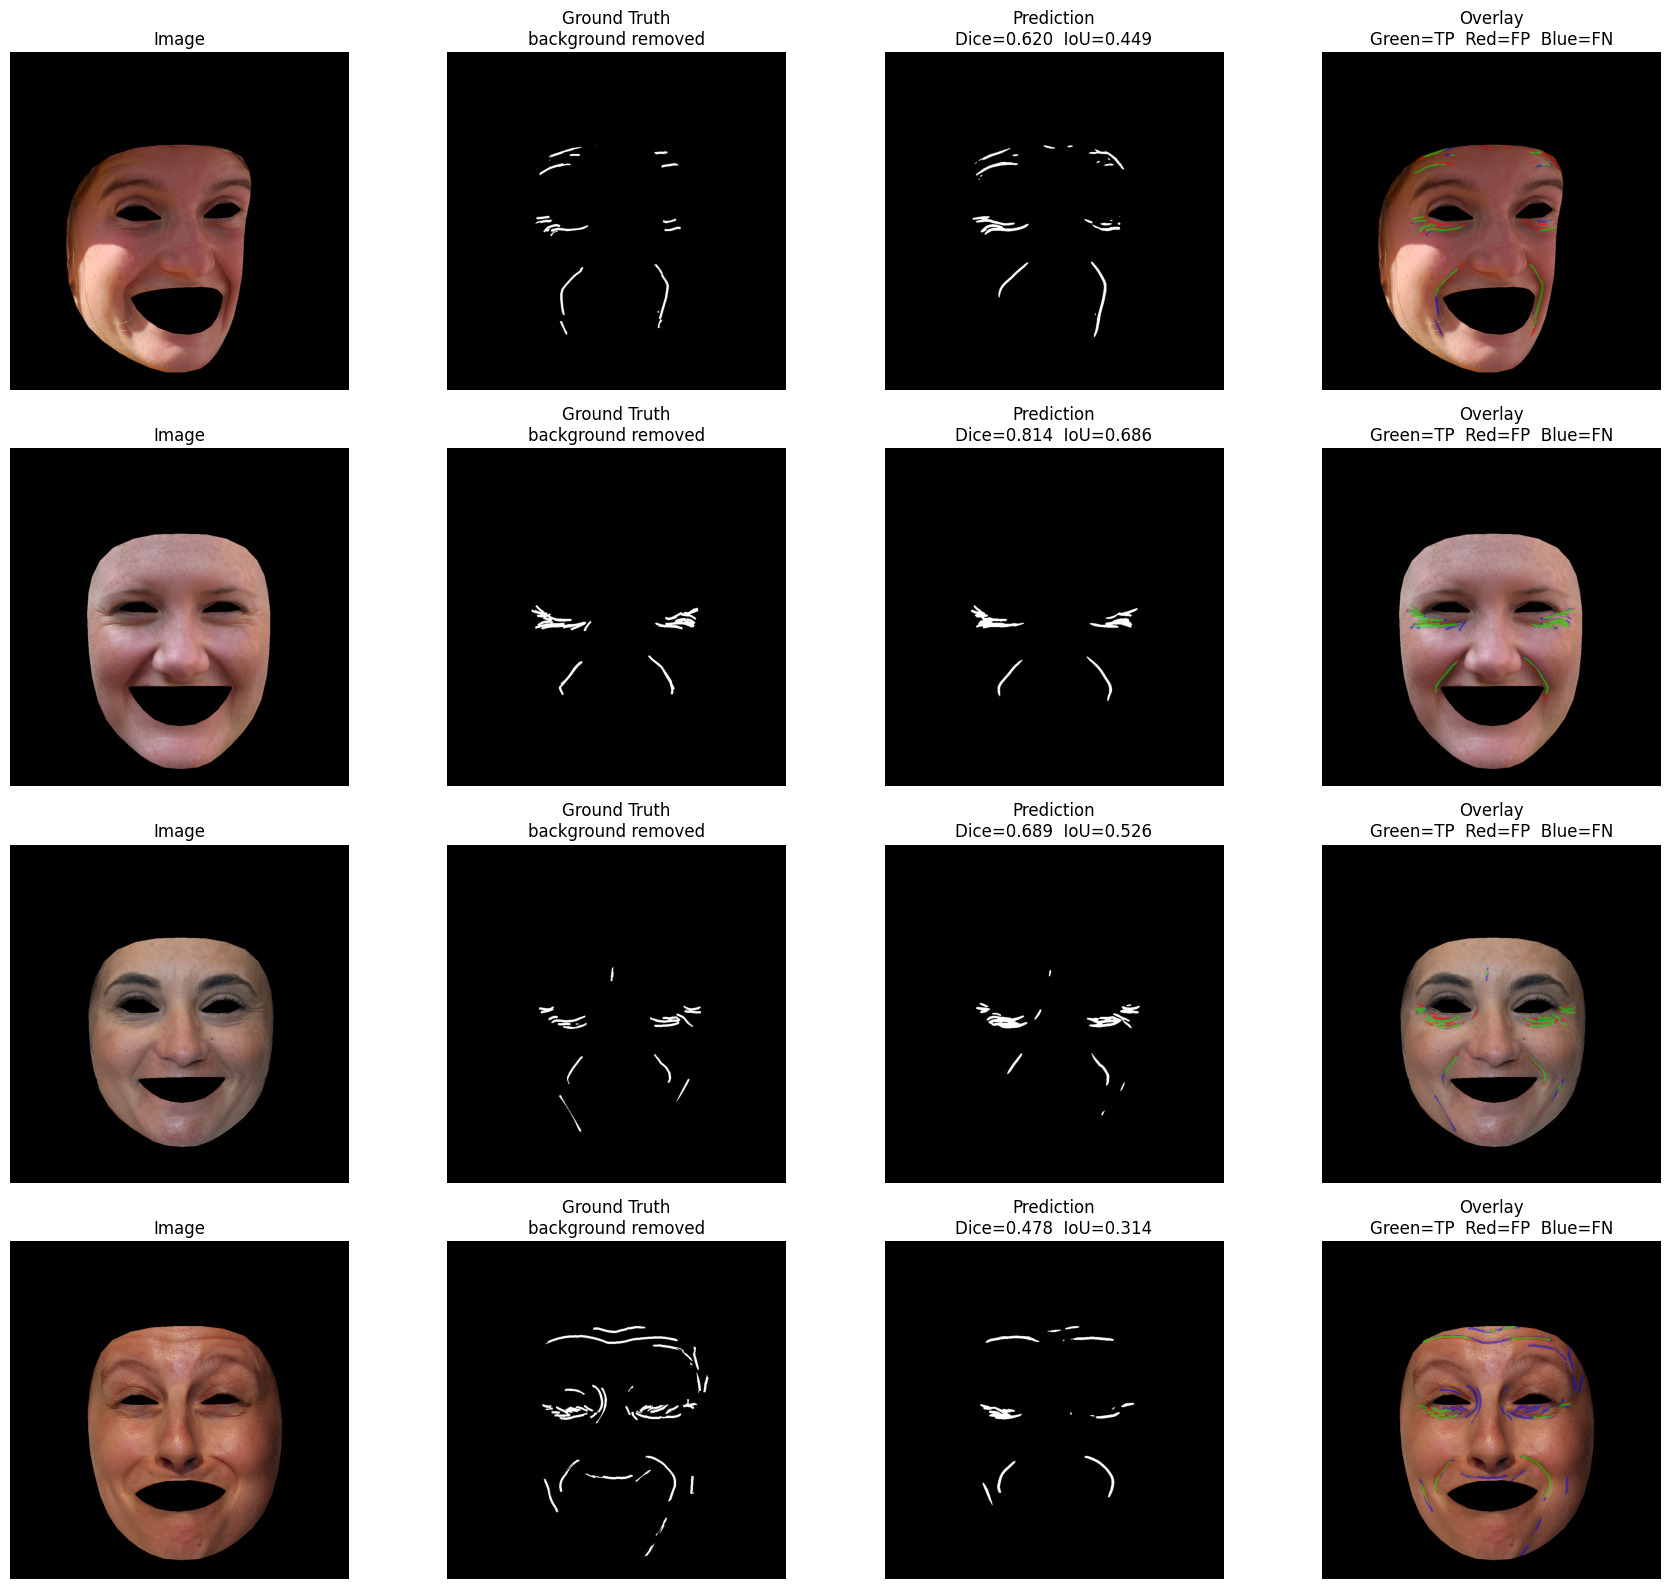

In [12]:
imgs_all = []
masks_all = []

for i, (imgs, masks) in enumerate(test_loader):
    if i >= 2:
        break
    imgs_all.append(imgs)
    masks_all.append(masks)

imgs_all = torch.cat(imgs_all, dim=0)
masks_all = torch.cat(masks_all, dim=0)

imgs, masks, probs, preds = get_predictions_unet(model, [(imgs_all, masks_all)], device)

visualize_predictions_grid(imgs, masks, preds, n=10)

In [9]:
model.eval()

te = validate_one_epoch(model, test_loader, device)

print("\n==== NEW TEST METRICS ====")
print(f"test loss: {te['loss']:.4f}")
print(f"test dice: {te['dice']:.4f}")
print(f"test iou : {te['iou']:.4f}")
print(f"test recall : {te['recall']:.4f}")
print(f"test precision : {te['precision']:.4f}")
print(f"test accuracy : {te['accuracy']:.4f}")


==== NEW TEST METRICS ====
test loss: 0.4007
test dice: 0.6295
test iou : 0.4680
test recall : 0.6398
test precision : 0.6566
test accuracy : 0.9950


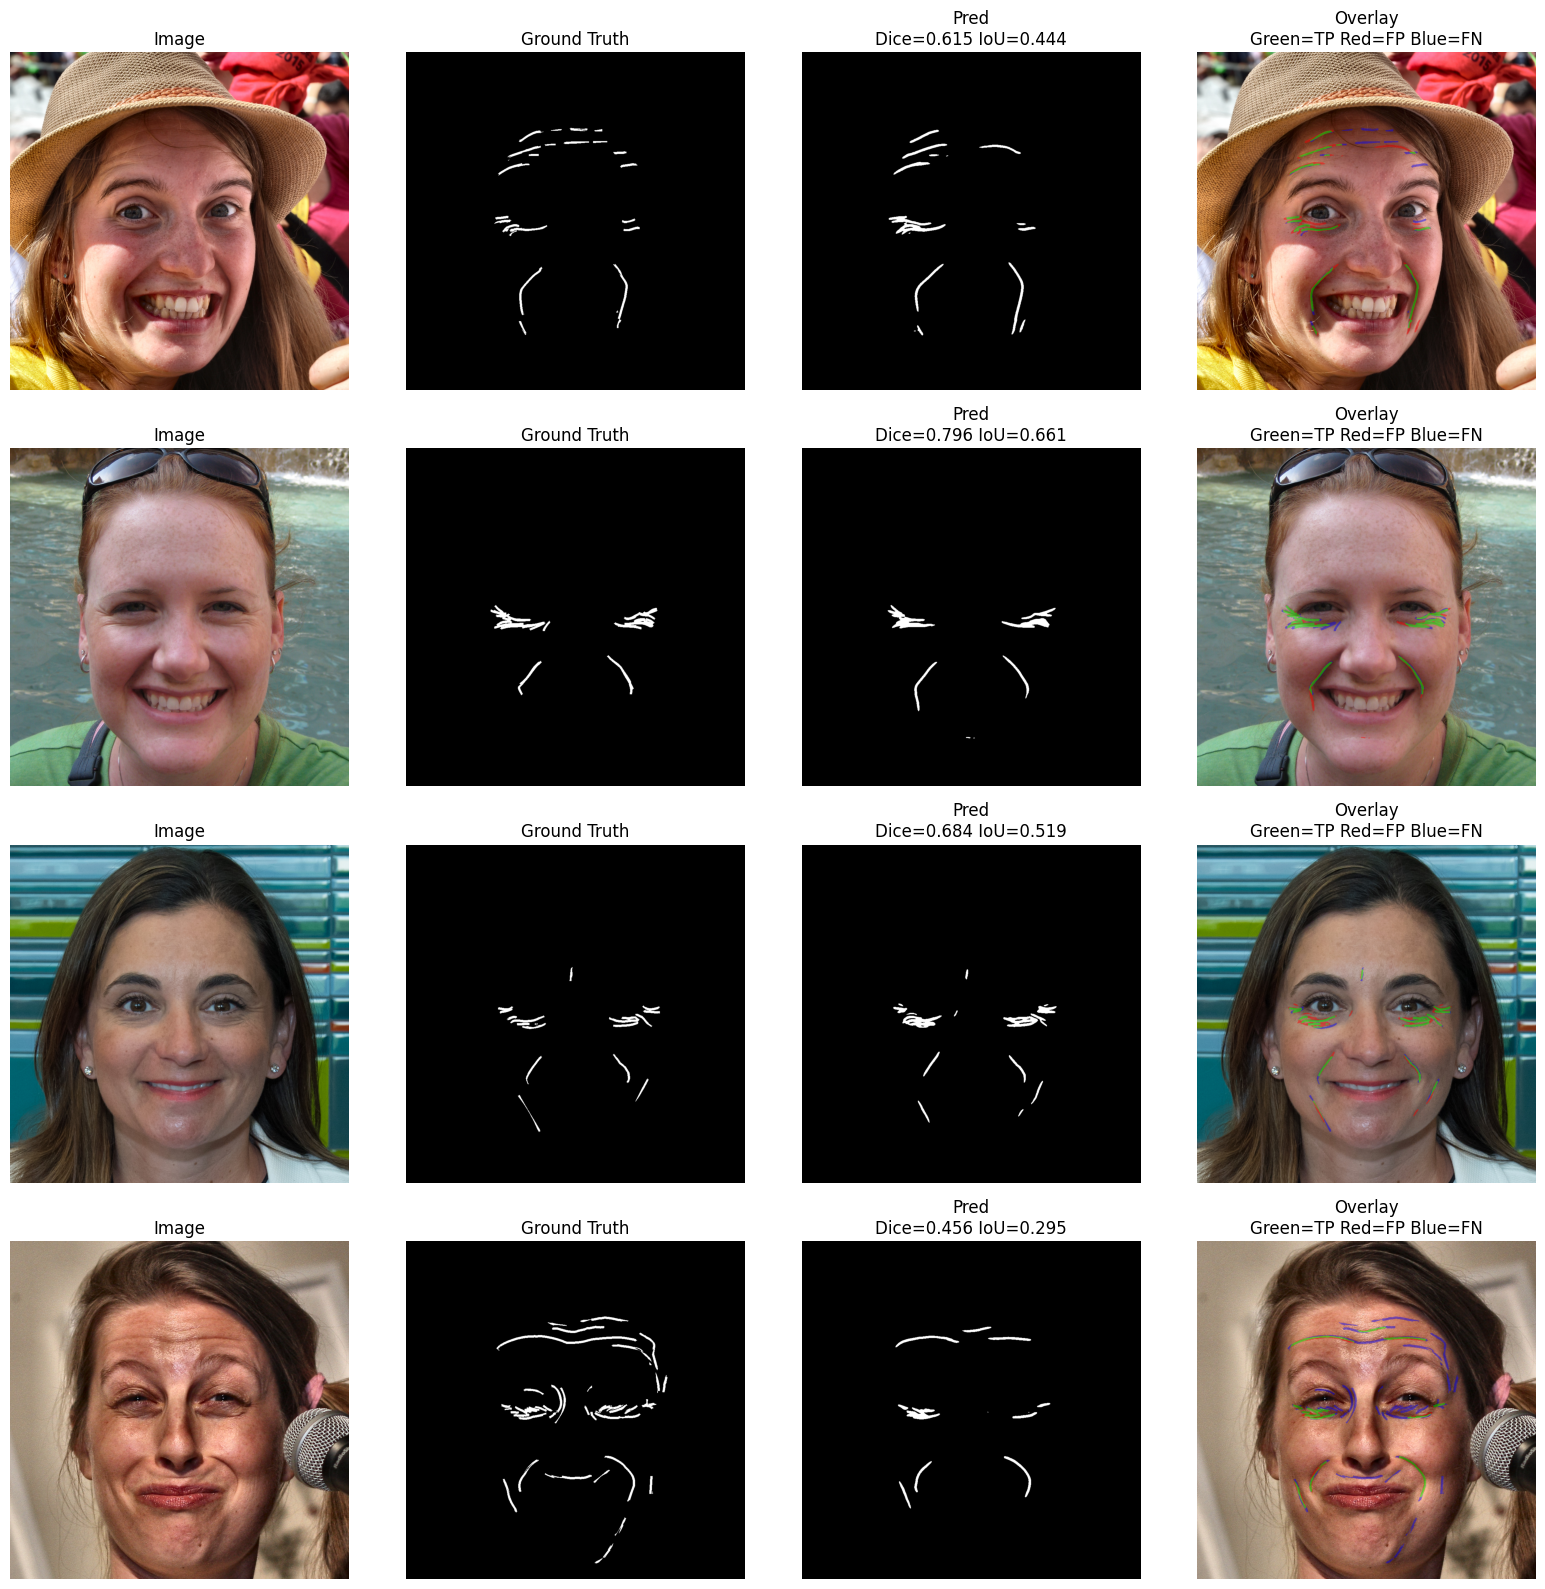

In [10]:
model.eval()

imgs_all = []
masks_all = []
logits_all = []

with torch.no_grad():
    for i, (imgs, masks) in enumerate(test_loader):
        if i >= 2:
            break

        imgs_all.append(imgs.cpu())
        masks_all.append(masks.cpu())

        imgs = imgs.to(device)
        logits = model(imgs)

        logits_all.append(logits.cpu())

imgs_all = torch.cat(imgs_all, dim=0)
masks_all = torch.cat(masks_all, dim=0)
logits_all = torch.cat(logits_all, dim=0)

show_predictions_overlay(
    imgs_all,
    masks_all,
    logits_all,
    n=4,
    threshold=0.5
)

In [9]:
model.eval()

te = validate_one_epoch(model, test_loader, device)

print("\n==== NEW TEST METRICS ====")
print(f"test loss: {te['loss']:.4f}")
print(f"test dice: {te['dice']:.4f}")
print(f"test iou : {te['iou']:.4f}")
print(f"test recall : {te['recall']:.4f}")
print(f"test precision : {te['precision']:.4f}")
print(f"test accuracy : {te['accuracy']:.4f}")


==== NEW TEST METRICS ====
test loss: 0.4019
test dice: 0.6282
test iou : 0.4665
test recall : 0.6370
test precision : 0.6543
test accuracy : 0.9950


In [11]:
import torch
import gc

gc.collect()
torch.cuda.empty_cache()

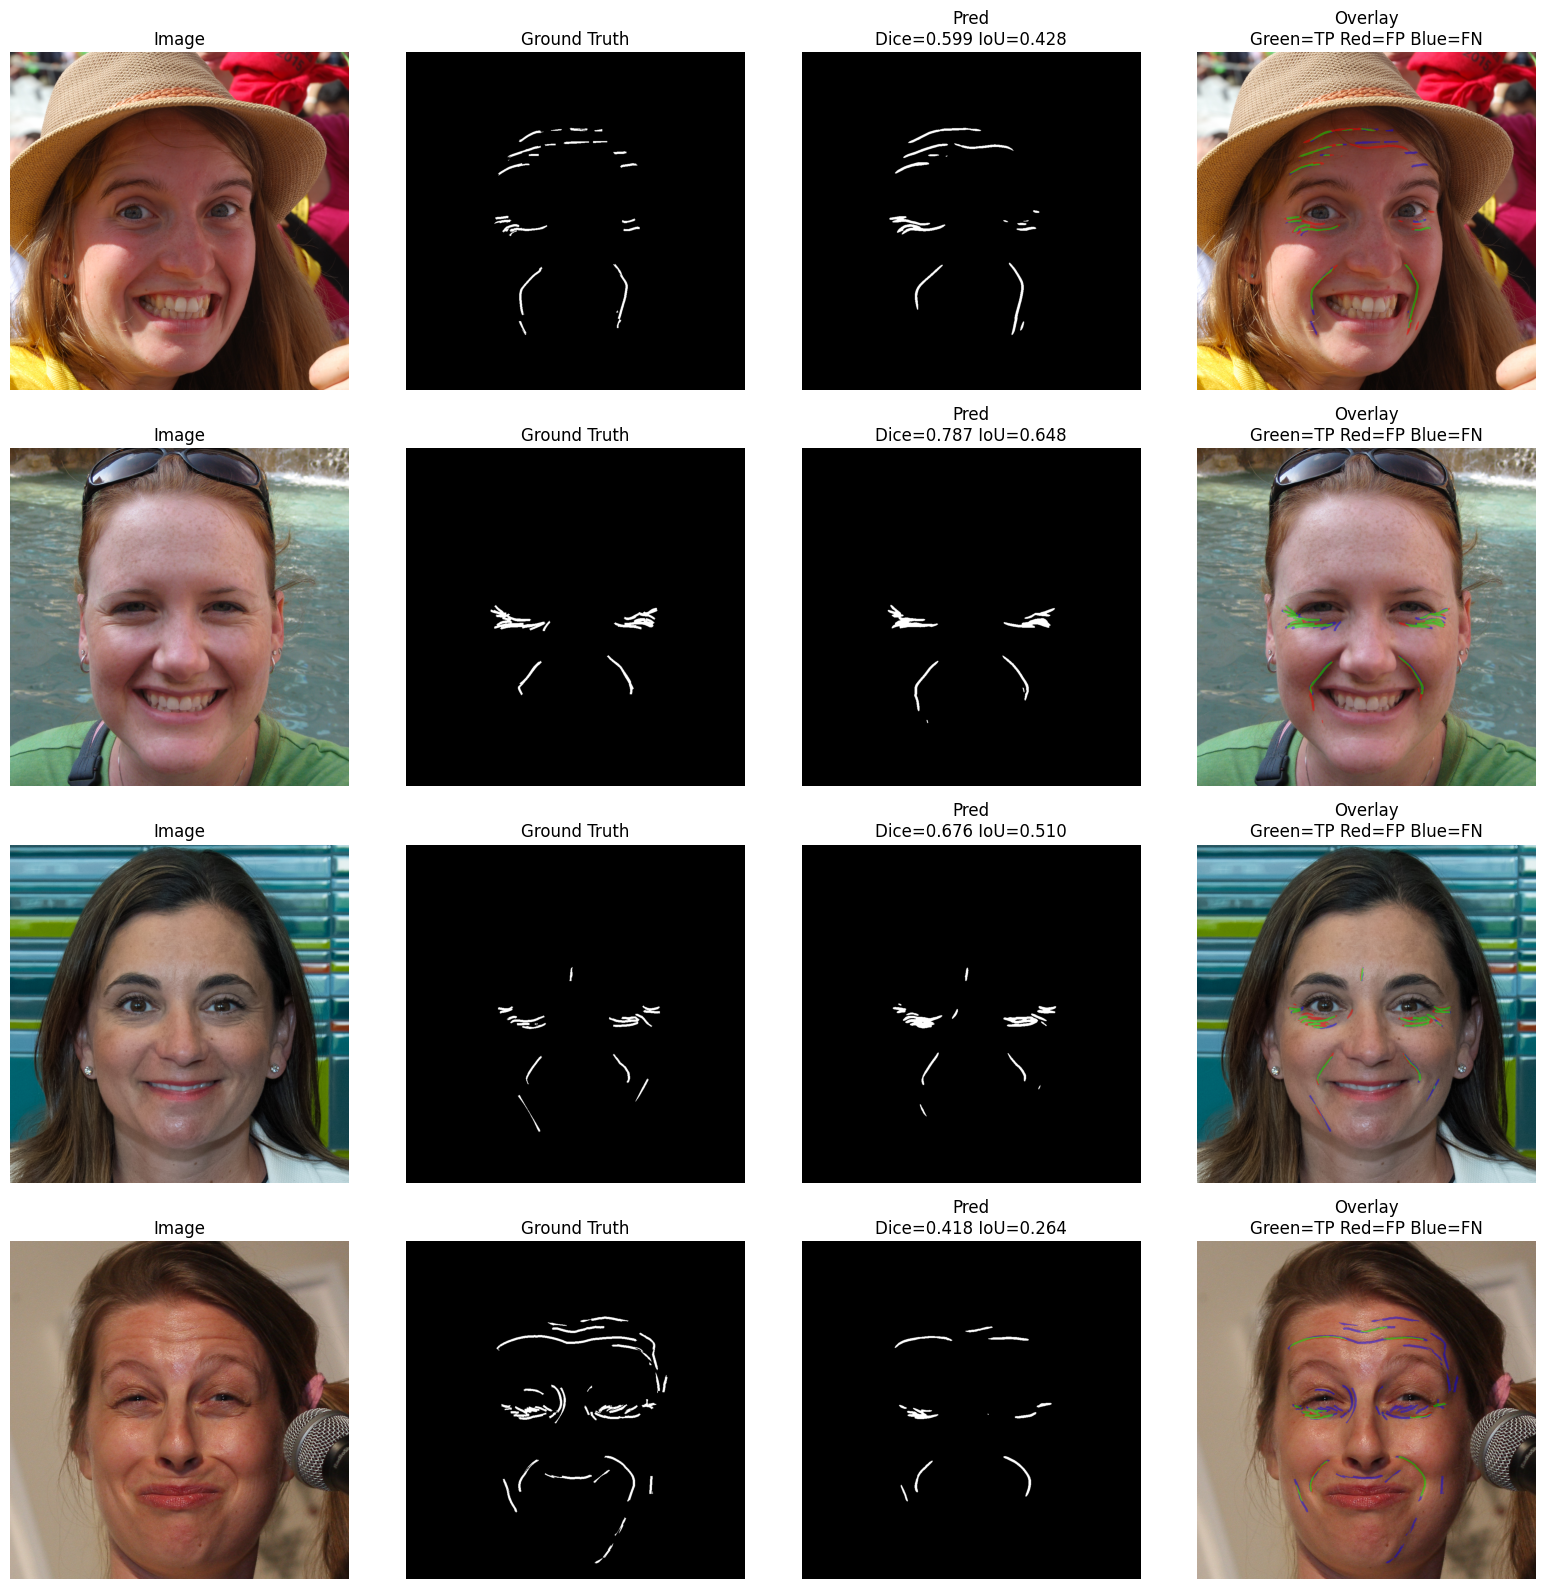

In [16]:
model.eval()

imgs_all = []
masks_all = []
logits_all = []

with torch.no_grad():
    for i, (imgs, masks) in enumerate(test_loader):
        if i >= 2:
            break

        imgs_all.append(imgs.cpu())
        masks_all.append(masks.cpu())

        imgs = imgs.to(device)
        logits = model(imgs)

        logits_all.append(logits.cpu())

imgs_all = torch.cat(imgs_all, dim=0)
masks_all = torch.cat(masks_all, dim=0)
logits_all = torch.cat(logits_all, dim=0)

show_predictions_overlay(
    imgs_all,
    masks_all,
    logits_all,
    n=4,
    threshold=0.5
)